<a href="https://colab.research.google.com/github/OleSpooky/README/blob/main/vacuum_gap_diagnostics_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

@dataclass
class VacuumGapMetrics:
    """Immutable record of the state-space insulation properties."""
    gap_width: float
    gap_depth: float
    curvature: float
    global_corr: float
    rolling_corr: np.ndarray

def contiguous_gap_width(mask: np.ndarray, ds: float) -> float:
    """Calculates the widest continuous region where the condition is met."""
    best = 0
    run = 0
    for flag in mask:
        if flag:
            run += 1
            best = max(best, run)
        else:
            run = 0
    return best * ds

def analyze_vacuum_gap(
    inner_state: np.ndarray,
    outer_state: np.ndarray,
    bins: int = 100,
    window: int = 50,
    eps: float = 1e-8,
    support_threshold: float = 0.02,
    plot: bool = True,
    title: str = "Vacuum Gap Resilience"
) -> Tuple[VacuumGapMetrics, Optional[plt.Figure]]:
    """
    Computes the structural insulation and coupling between an inner and outer state.
    """
    inner_state = np.asarray(inner_state, dtype=float)
    outer_state = np.asarray(outer_state, dtype=float)

    if inner_state.shape != outer_state.shape:
        raise ValueError("inner_state and outer_state must have the same length")

    value_min = min(inner_state.min(), outer_state.min())
    value_max = max(inner_state.max(), outer_state.max())

    hist_i, edges = np.histogram(inner_state, bins=bins, density=True, range=(value_min, value_max))
    hist_o, _ = np.histogram(outer_state, bins=edges, density=True)

    centers = 0.5 * (edges[:-1] + edges[1:])
    ds = centers[1] - centers[0]

    # 1. Support mask to suppress tail hallucinations
    support_mask = (hist_i + hist_o) > support_threshold
    d = np.full_like(hist_i, np.nan, dtype=float)
    d[support_mask] = hist_i[support_mask] / (hist_o[support_mask] + eps)

    # 2. Fill unsupported regions with neutral ratio, then smooth for geometric extraction
    d_fill = np.where(np.isfinite(d), d, 1.0)
    d_smooth = np.convolve(d_fill, np.ones(5) / 5, mode="same")

    # 3. Extract Observables
    gap_mask = d_smooth < 1.0
    gap_width = contiguous_gap_width(gap_mask, ds)

    min_idx = int(np.argmin(d_smooth))
    gap_depth = 1.0 - d_smooth[min_idx]

    if 0 < min_idx < len(d_smooth) - 1:
        curvature = (d_smooth[min_idx + 1] - 2 * d_smooth[min_idx] + d_smooth[min_idx - 1]) / ds**2
    else:
        curvature = np.nan

    # 4. Rolling & Global Correlation
    roll_corr = []
    for i in range(len(inner_state) - window + 1):
        a = inner_state[i:i + window]
        b = outer_state[i:i + window]
        if np.std(a) < eps or np.std(b) < eps:
            roll_corr.append(np.nan)
        else:
            roll_corr.append(np.corrcoef(a, b)[0, 1])
    roll_corr = np.array(roll_corr)
    r = float(np.corrcoef(inner_state, outer_state)[0, 1])

    metrics = VacuumGapMetrics(
        gap_width=gap_width,
        gap_depth=gap_depth,
        curvature=curvature,
        global_corr=r,
        rolling_corr=roll_corr
    )

    fig = None
    if plot:
        fig = plt.figure(figsize=(14, 10))
        gs = fig.add_gridspec(2, 2)

        ax1 = fig.add_subplot(gs[0, 0])
        # Plotting 'd' directly so NaNs break the line, showing literal support gaps
        ax1.plot(centers, d, lw=1.5, color='gray', alpha=0.5, label=r"$d(s)$ support-filtered")
        ax1.plot(centers, d_smooth, lw=2.5, color='blue', label=r"$d(s)$ smoothed")
        ax1.fill_between(centers, 0, 1, where=gap_mask, color='red', alpha=0.3, label="Contiguous Gap")
        ax1.axvline(centers[min_idx], color="k", linestyle="--", label="Trough")
        ax1.set_title(f"Density Ratio | Contiguous Width = {gap_width:.3f}")
        ax1.set_xlabel("State value")
        ax1.set_ylabel(r"$d(s)$")
        ax1.legend()

        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(np.linspace(0, 1, len(roll_corr)), roll_corr, color='green', lw=2)
        ax2.axhline(0, color="gray", linestyle="--")
        ax2.set_title("Rolling Inner ↔ Outer Correlation")
        ax2.set_xlabel("Normalized index")
        ax2.set_ylabel("Pearson r")

        ax3 = fig.add_subplot(gs[1, :])
        cent_idx = np.arange(window // 2, window // 2 + len(roll_corr))
        sc = ax3.scatter(
            inner_state[cent_idx], outer_state[cent_idx],
            c=np.nan_to_num(roll_corr, nan=0.0), cmap="RdYlGn", alpha=0.6
        )
        ax3.arrow(0, 0, r, 0, head_width=0.08, color="purple", label="Global correlation")
        ax3.add_patch(Circle((0, 0), radius=1, fill=False, linestyle="--", color="red", label="Reference threshold"))
        ax3.add_patch(Circle((0, 0), radius=2, fill=False, linestyle="--", color="blue", label="Reference outer frame"))
        ax3.set_xlabel("Inner State")
        ax3.set_ylabel("Outer State")
        ax3.set_title("State Coupling Plane")
        ax3.grid(True)
        ax3.legend()

        fig.colorbar(sc, ax=ax3, label="Local rolling correlation")
        plt.suptitle(f"{title}\nGap Depth: {gap_depth:.3f} | Trough Curvature: {curvature:.3f}", fontsize=14)
        plt.tight_layout()

    return metrics, fig

def batch_analyze_epochs(
    history_array: np.ndarray,
    inner_mask: np.ndarray,
    outer_mask: np.ndarray,
    epochs: list
) -> Dict[int, VacuumGapMetrics]:
    """
    Runs the diagnostic across multiple epochs, returning a timeline of insulation metrics.
    history_array expected shape: (epochs, time_steps, nodes)
    """
    timeline = {}
    for ep in epochs:
        in_state = np.mean(history_array[ep, :, inner_mask], axis=1)
        out_state = np.mean(history_array[ep, :, outer_mask], axis=1)

        metrics, _ = analyze_vacuum_gap(in_state, out_state, plot=False)
        timeline[ep] = metrics

    return timeline

Contiguous Gap Width: 2.0577
Gap Depth: 1.0000
Trough Curvature: 18.1376
Global correlation r: -0.0078


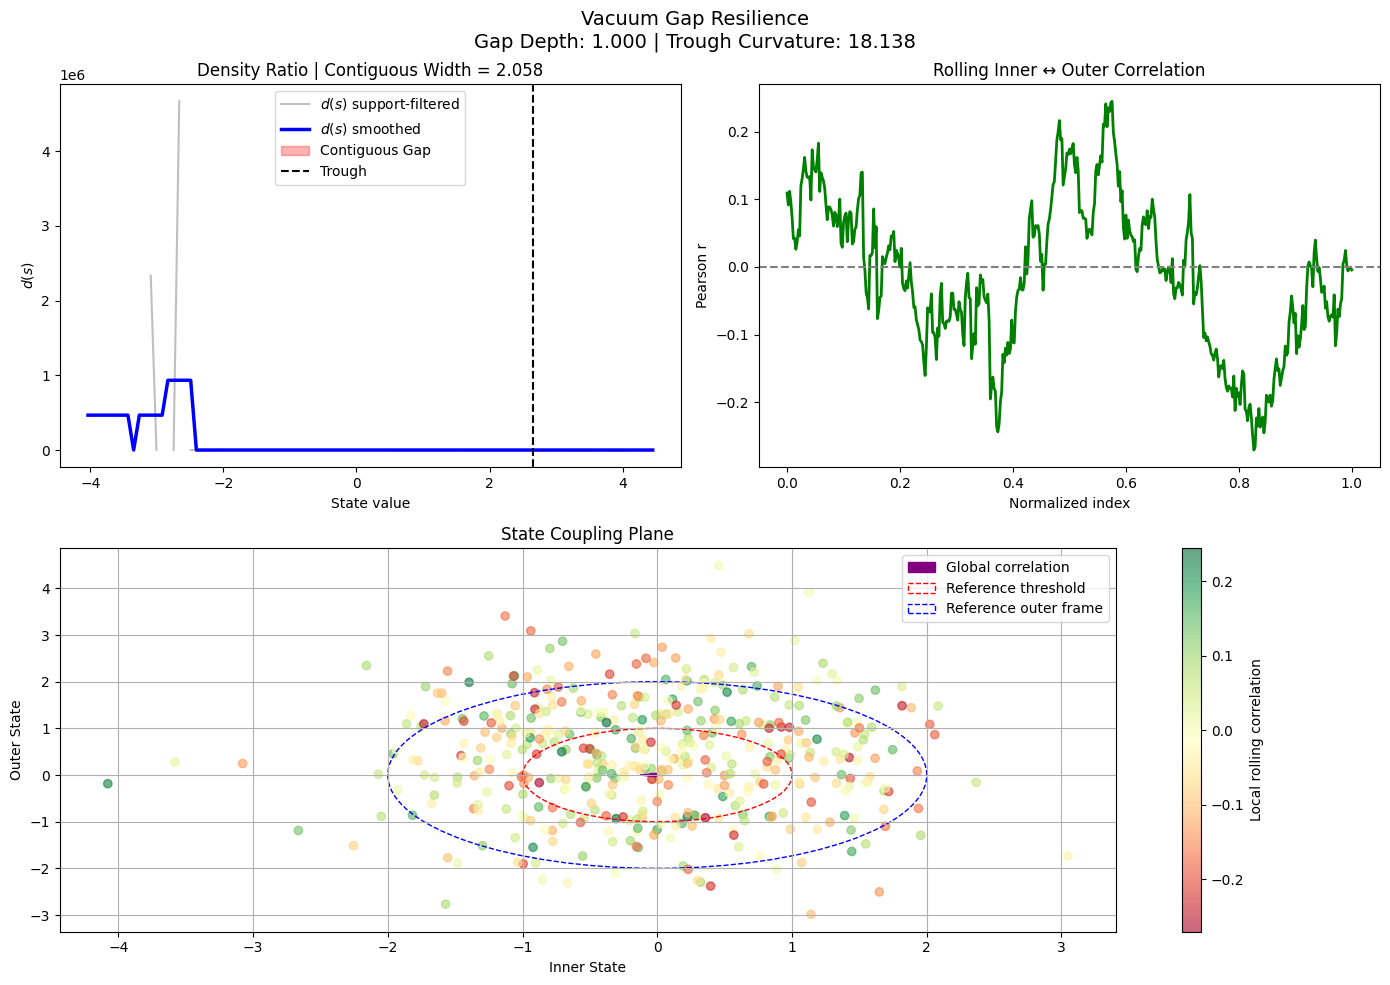

In [52]:
inner = np.random.normal(0, 1, 500)
outer = np.random.normal(0.5, 1.2, 500)
metrics, fig = analyze_vacuum_gap(inner, outer)

# Display the metrics
print(f"Contiguous Gap Width: {metrics.gap_width:.4f}")
print(f"Gap Depth: {metrics.gap_depth:.4f}")
print(f"Trough Curvature: {metrics.curvature:.4f}")
print(f"Global correlation r: {metrics.global_corr:.4f}")

if fig:
    plt.show()

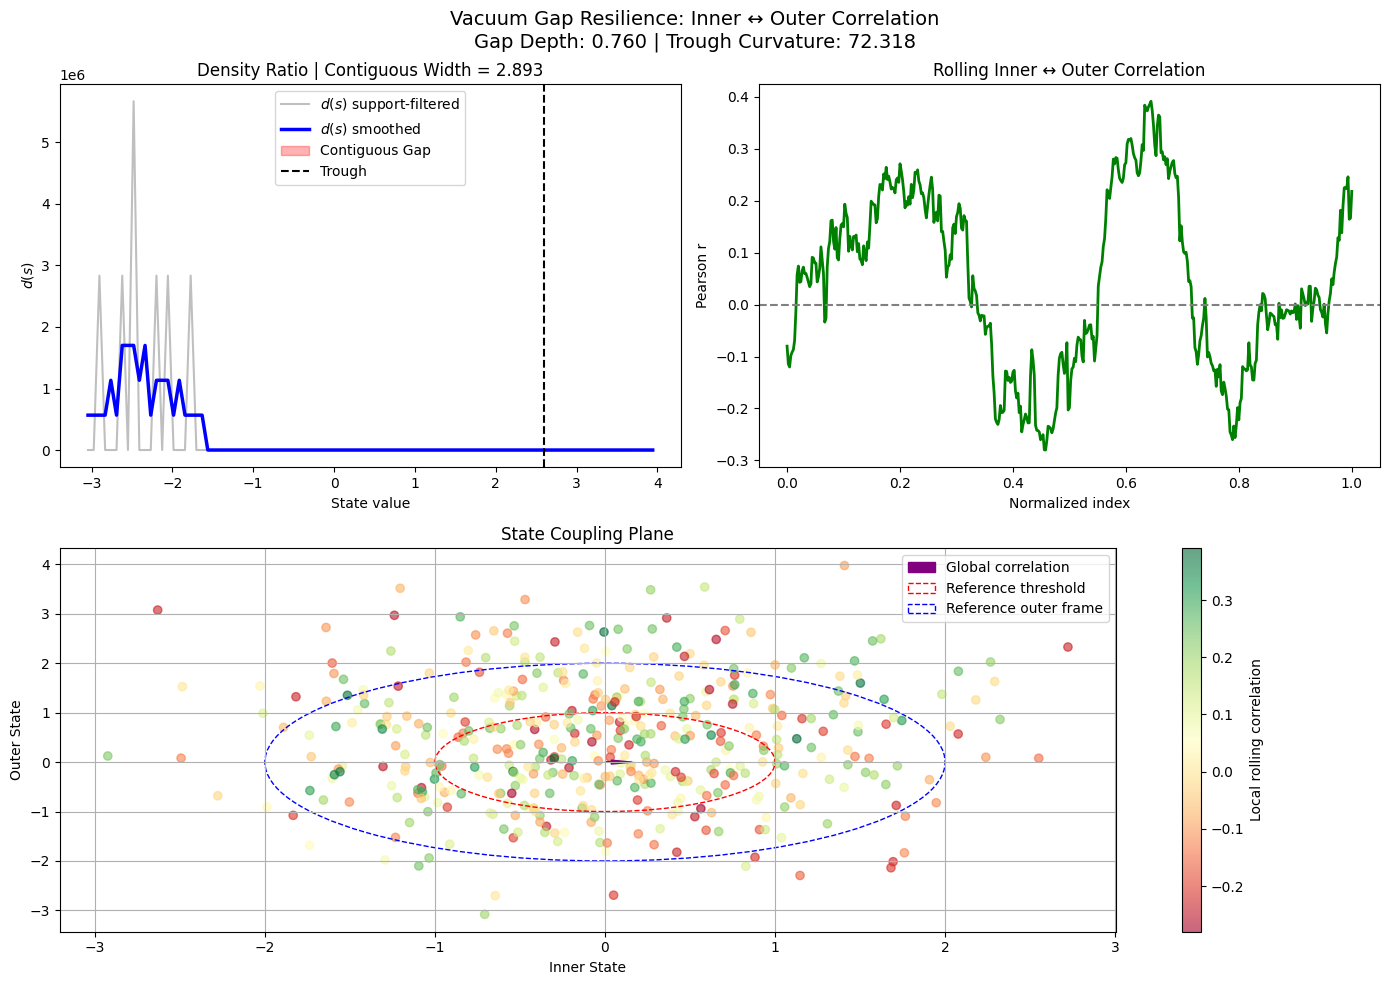

Contiguous Gap Width: 2.8928
Gap Depth: 0.7600
Trough Curvature: 72.3181
Global correlation r: 0.0369


In [53]:
inner = np.random.normal(0, 1, 500)
outer = np.random.normal(0.5, 1.2, 500)
fig, gap_w, gap_d, curv = plot_vacuum_gap_resilience(inner, outer)

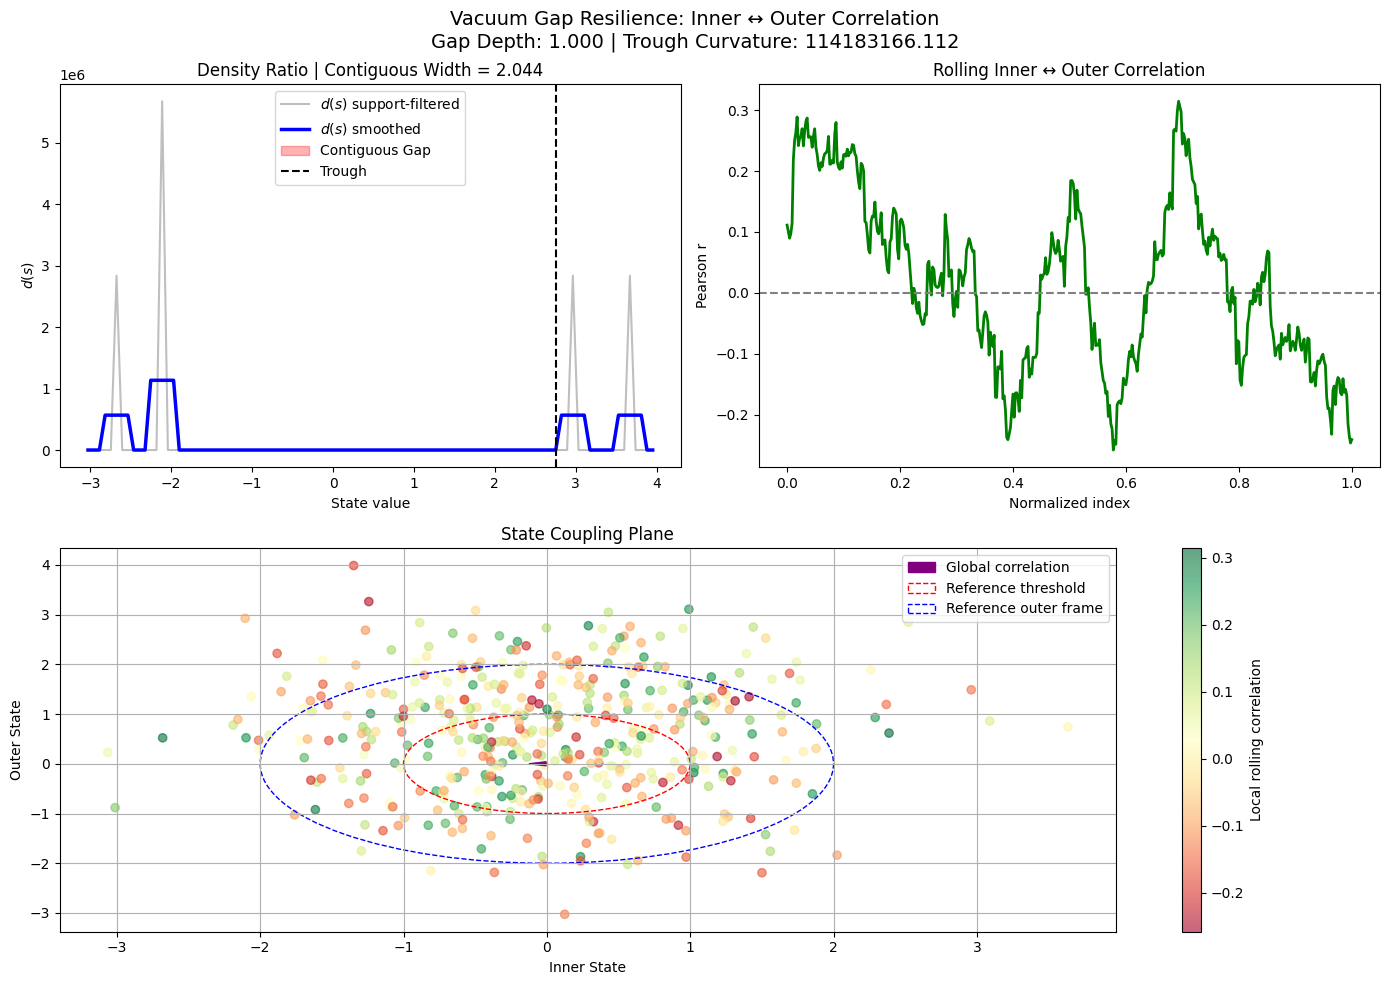

Contiguous Gap Width: 2.0443
Gap Depth: 1.0000
Trough Curvature: 114183166.1121
Global correlation r: -0.0055


In [54]:
inner = np.random.normal(0, 1, 500)
outer = np.random.normal(0.5, 1.2, 500)

fig, gap_w, gap_d, curv = plot_vacuum_gap_resilience(inner, outer)

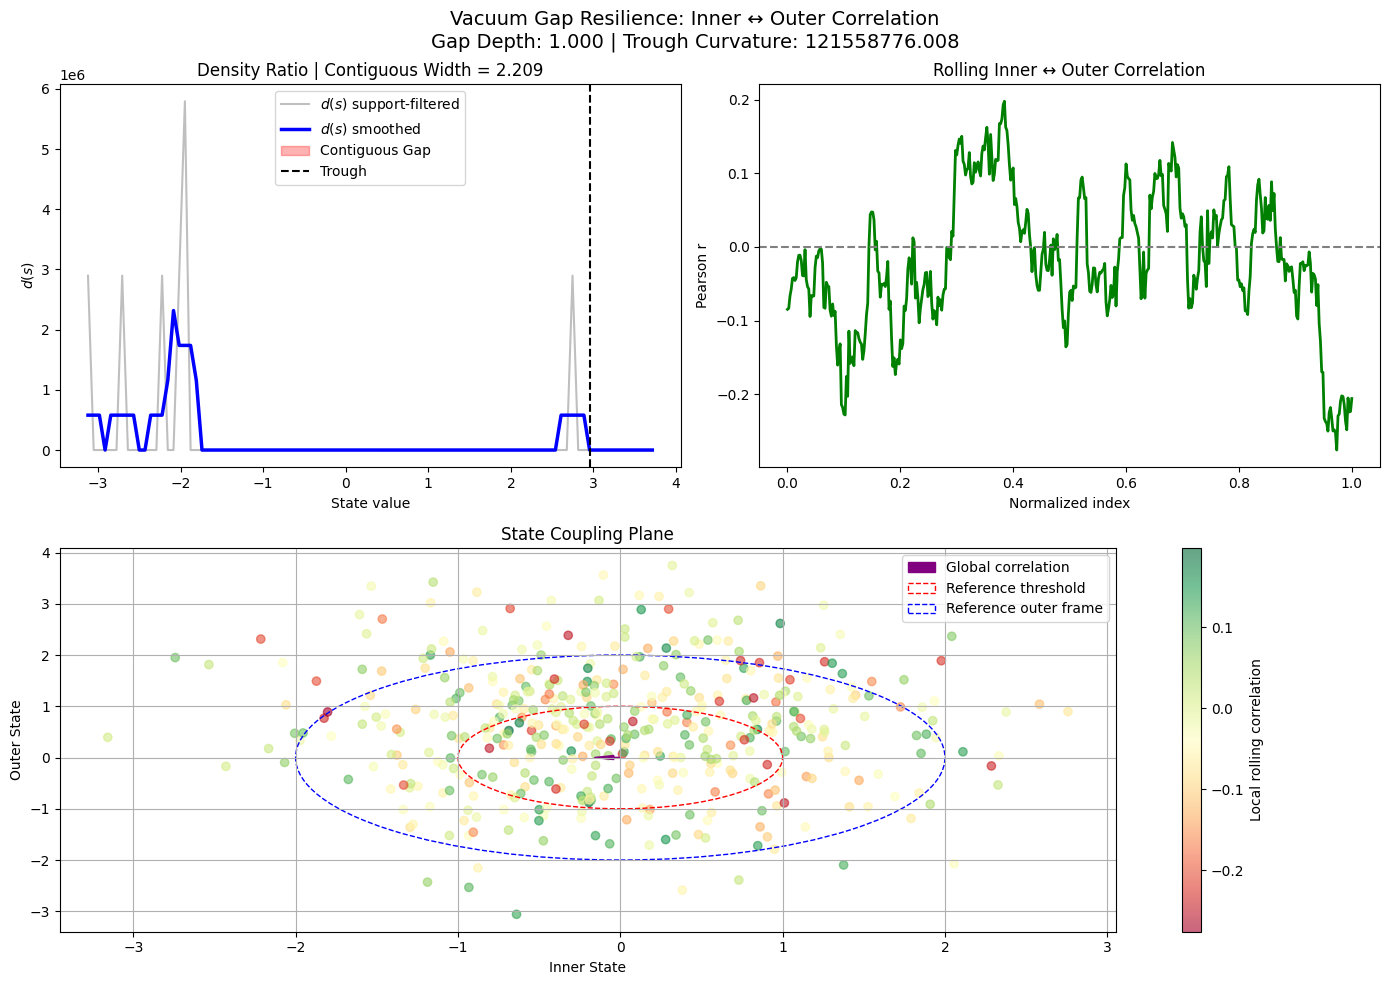

Contiguous Gap Width: 2.2092
Gap Depth: 1.0000
Trough Curvature: 121558776.0076
Global correlation r: -0.0402


In [55]:
# Your inner (S/H core) and outer (R) states from any lattice run
inner = np.random.normal(0, 1, 500)   # or your actual SovereignNode states
outer = np.random.normal(0.5, 1.2, 500)  # shifted for correlation demo

fig, gap_w, gap_d, curv = plot_vacuum_gap_resilience(inner, outer)

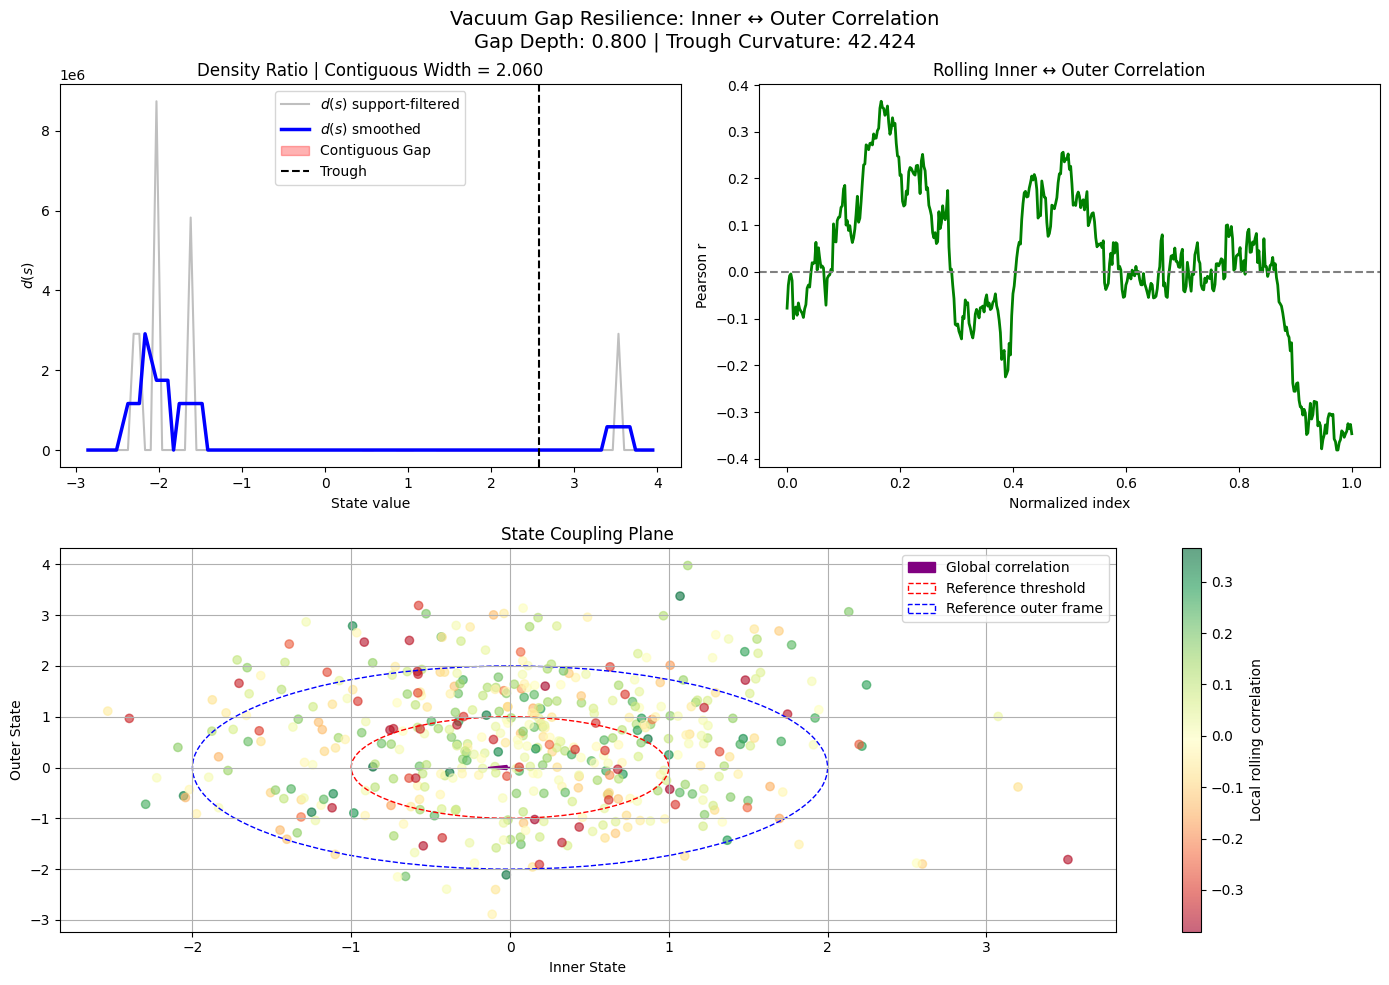

Contiguous Gap Width: 2.0598
Gap Depth: 0.8000
Trough Curvature: 42.4242
Global correlation r: -0.0188


In [56]:
inner = np.random.normal(0, 1, 500)
outer = np.random.normal(0.5, 1.2, 500)

fig, gap_w, gap_d, curv = plot_vacuum_gap_resilience(inner, outer)